  Linear e monotônica       rho=+0.96  rho_s=+0.97  I=1.31
  Não linear e monotônica   rho=+0.88  rho_s=+0.92  I=1.04
  Não linear e monotônica   rho=+0.91  rho_s=+0.95  I=1.58
  Não linear e não monotônica  rho=-0.08  rho_s=-0.09  I=1.17
  Não linear e não monotônica  rho=+0.05  rho_s=+0.07  I=0.89
  Independentes             rho=+0.00  rho_s=-0.00  I=0.00


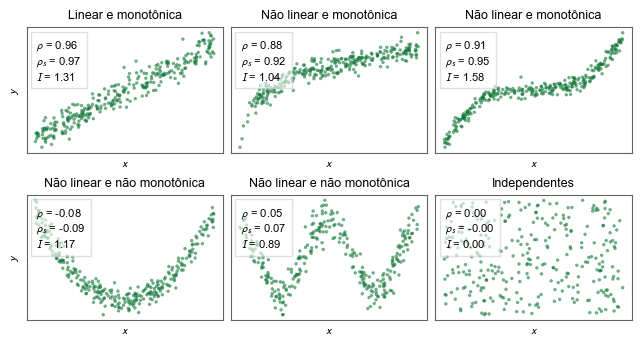

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

# ----------------------------------------------------------------------
# Estilo (ajuste conforme o padrao da dissertacao)
# ----------------------------------------------------------------------

ACCENT = "#117738"       # cor dos pontos  "#3D598B"
SEED = 2
N = 300              # numero de observacoes por painel

rng = np.random.default_rng(SEED)


def info_mutua(x, y):
    return mutual_info_regression(
        x.reshape(-1, 1), y, discrete_features=False, random_state=SEED
    )


def medidas(x, y):
    r = pearsonr(x, y)[0]
    rs = spearmanr(x, y)[0]
    im = info_mutua(x, y)[0]
    return r, rs, im


# ----------------------------------------------------------------------
# Definicao das relacoes (titulo, x, y)
# ----------------------------------------------------------------------
def gerar_relacoes():
    relacoes = []

    # 1) Linear
    x = rng.uniform(-3, 3, N)
    y = x + rng.normal(0, 0.5, N)
    relacoes.append(("Linear e monotônica", x, y))

    # 2) Monotonica nao-linear
    x = rng.uniform(0.1, 10, N)
    y = np.log(x) + rng.normal(0, 0.25, N)
    relacoes.append(("Não linear e monotônica", x, y))
    
    # 3) Monotonica nao-linear (cubica)
    x = rng.uniform(-3, 3, N)
    y = x ** 3 + rng.normal(0, 2.0, N)
    relacoes.append(("Não linear e monotônica", x, y))

    # 4) Quadratica (nao-monotonica)
    x = rng.uniform(-3, 3, N)
    y = x ** 2 + rng.normal(0, 0.7, N)
    relacoes.append(("Não linear e não monotônica", x, y))

    # 5) Periodica par (nao-monotonica): cosseno, correlacao proxima de zero
    x = rng.uniform(-3, 3, N)
    y = np.cos(2.0 * x) + rng.normal(0, 0.3, N)
    relacoes.append(("Não linear e não monotônica", x, y))

    # 6) Independentes
    x = rng.uniform(-3, 3, N)
    y = rng.uniform(-3, 3, N)
    relacoes.append(("Independentes", x, y))

    return relacoes


relacoes = gerar_relacoes()

# ----------------------------------------------------------------------
# Figura: 2 linhas x 3 colunas
# ----------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "axes.titlesize": 9,
    "axes.labelsize": 8

})

cm= 1/2.54
fig, axes = plt.subplots(2, 3, figsize=(16*cm, 8.5*cm), layout= "constrained")


for ax, (titulo, x, y) in zip(axes.ravel(), relacoes):
    r, rs, im = medidas(x, y)

    ax.scatter(x, y, s=6, color=ACCENT, alpha=0.6, edgecolor="none")
    ax.set_title(titulo)

    # caixa com os tres valores
    texto = (f"$\\rho$ = {r:.2f}\n"
             f"$\\rho_s$ = {rs:.2f}\n"
             f"$I$ = {im:.2f}")
    ax.text(0.05, 0.9, texto, transform=ax.transAxes,
            ha="left", va="top", fontsize=8,
            bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=0.6))

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("$y$")

    ax.set_xlabel("$x$")

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#646363")


fig.savefig("figuras/exemplo_comparacao_selecoes.png")

# valores no console, para conferencia
for titulo, x, y in relacoes:
    r, rs, im = medidas(x, y)
    print(f"  {titulo:24s}  rho={r:+.2f}  rho_s={rs:+.2f}  I={im:.2f}")